In [2]:
from dotenv import load_dotenv
load_dotenv()

True

# Chain


## Messages

In [3]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

print(messages)

for m in messages:
    m.pretty_print()

[AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Model'), HumanMessage(content="Yes, that's right.", additional_kwargs={}, response_metadata={}, name='Lance'), AIMessage(content='Great, what would you like to learn about.', additional_kwargs={}, response_metadata={}, name='Model'), HumanMessage(content='I want to learn about the best place to see Orcas in the US.', additional_kwargs={}, response_metadata={}, name='Lance')]
================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn 

## Chat Models


In [4]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")
result = llm.invoke(messages)
print(result)
type(result)

content='The United States offers several excellent locations to spot Orcas, also known as Killer Whales. Here are some of the best places to see them:\n\n1. **San Juan Islands, Washington**: The San Juan Islands are one of the most popular and reliable places to see Orcas in the US. The islands are home to a large resident population of Southern Resident Orcas, and you can take guided tours from towns like Friday Harbor or Roche Harbor.\n2. **Puget Sound, Washington**: Puget Sound is another great location to spot Orcas, particularly in the areas around Seattle and Tacoma. You can take a guided tour or visit the Puget Sound Orca Recovery Day event.\n3. **Olympic National Park, Washington**: Olympic National Park offers a unique opportunity to see Orcas in their natural habitat, particularly in the coastal areas around Kalaloch and Ruby Beach.\n4. **Monterey Bay, California**: Monterey Bay is known for its diverse marine life, and Orcas can be spotted here, particularly during the wint

langchain_core.messages.ai.AIMessage

## Tools


In [5]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [6]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])
tool_call

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bz3mm3f40', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 232, 'total_tokens': 251, 'completion_time': 0.07044582, 'prompt_time': 0.033345801, 'queue_time': 0.014490126, 'total_time': 0.103791621}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f613fbaf-b9e6-4a24-ba2a-c86f6e62028c-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'bz3mm3f40', 'type': 'tool_call'}], usage_metadata={'input_tokens': 232, 'output_tokens': 19, 'total_tokens': 251})

In [19]:
llm_with_tools.invoke([HumanMessage(content=f"Hello", name="Lance")])

AIMessage(content="I'm here to help. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 225, 'total_tokens': 239, 'completion_time': 0.033623502, 'prompt_time': 0.025213756, 'queue_time': 0.194804015, 'total_time': 0.058837258}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3f3b593e33', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--4b9a26a2-8d85-43bb-b3f1-53b5660f5634-0', usage_metadata={'input_tokens': 225, 'output_tokens': 14, 'total_tokens': 239})

In [7]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'bz3mm3f40',
  'type': 'tool_call'}]

## Using messages as state

In [10]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers

In [11]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [ ]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

In [9]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='eb49a8cd-4352-4201-aeda-d3796ee112d9'),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='db0d8d8b-4d69-45b1-8c4e-4a565502f704'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='976f490c-2d0d-4c51-a8ad-25197d3903a6')]

## Our graph

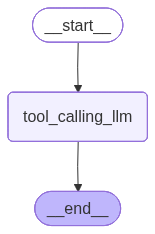

In [12]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
print(messages)
for m in messages['messages']:
    m.pretty_print()

{'messages': [HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='04bcc17c-6c98-4208-9911-6c906db7b379'), AIMessage(content="I'm happy to chat with you, but I don't see a specific question or task that I can help you with. Is there something I can assist you with or would you like to just say hello?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 226, 'total_tokens': 269, 'completion_time': 0.180122144, 'prompt_time': 0.015182225, 'queue_time': 0.145593846, 'total_time': 0.195304369}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--6308ecfc-7e9b-462b-93a5-ccc2c1e2edd5-0', usage_metadata={'input_tokens': 226, 'output_tokens': 43, 'total_tokens': 269})]}
================================ Human Message =================================

Hello!
================================== Ai Message ==========

In [15]:
messages = graph.invoke({"messages":[HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")]})
print(messages)
for m in messages['messages']:
    m.pretty_print()

{'messages': [HumanMessage(content='What is 2 multiplied by 3', additional_kwargs={}, response_metadata={}, name='Lance', id='f78bcb7c-0934-4128-949d-b9345b3a7779'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'x5t55eh03', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 232, 'total_tokens': 251, 'completion_time': 0.067299129, 'prompt_time': 0.012549692, 'queue_time': 0.054033716, 'total_time': 0.079848821}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--fdb5e574-b0f8-4df4-b168-40d6476e2f90-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'x5t55eh03', 'type': 'tool_call'}], usage_metadata={'input_tokens': 232, 'output_tokens': 19, 'total_tokens': 251})]}
================================ Human Message ==============